# Advanced Machine Learning - Project 1

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [32]:
from src.fista import FistaLogisticRegression

## FISTA Algorithm (Fast Iterative Shrinkage-Thresholding Algorithm)

The FISTA (Fast Iterative Shrinkage-Thresholding Algorithm) algorithm is used to optimize problems that can be split into two parts: a smooth (differentiable) part and a non-smooth (non-differentiable but convex) part.

### Problem Formulation

$$\min_{\mathbf{w}, b} F(\mathbf{w}, b) = f(\mathbf{w}, b) + g(\mathbf{w})$$

**Smooth part** $f(\mathbf{w}, b)$ (logistic loss for binary classification $y_i \in \{-1, 1\}$):
$$f(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \log(1+e^{-y_i(\mathbf{w}^T\mathbf{x}_i+b)})$$

**Non-smooth part** $g(\mathbf{w})$ (L1 penalty):
$$g(\mathbf{w}) = \lambda\|\mathbf{w}\|_1$$

### FISTA Steps
The paper by Beck & Teboulle (2009) outlines "FISTA with constant stepsize" using the following steps:
- Input: $L = L(f)$ — A Lipschitz constant of $\nabla f$.
- Step 0: Take $y_1 = x_0 \in \mathbb{R}^n$, $t_1 = 1$.
- Step $k$ ($k \ge 1$): Compute:
    1. $x_k = p_L(y_k)$ 
    2. $t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$ 
    3. $y_{k+1} = x_k + \left(\frac{t_k - 1}{t_{k+1}}\right)(x_k - x_{k-1})$ 


In the paper, the Proximal Operator ($p_L$) is the core building block of both ISTA and FISTA. It is introduced in Section 2.3 ("The basic approximation model"). With some algebraic manipulation, the authors show that the proximal step can be simplified to a shrinkage (soft-thresholding) operation when the non-smooth part is the L1 norm:

$$p_L(y) = \mathcal{T}_{\lambda/L} \left( y - \frac{1}{L} \nabla f(y) \right)$$

where 

$$\mathcal{T}_{\alpha}(z) = \text{sign}(z) \cdot \max(|z| - \alpha, 0)$$
 is the shrinkage operator.

### Algorithm implementation 

**Initialization:** `x_prev = 0`, `b_prev = 0`, `y_k = x_prev`, `y_k_b = b_prev`, `t_k = 1`

**For each iteration:**

#### Step 1: Compute Gradient
```
grad_x, grad_b = _compute_gradient(X, y, y_k, y_k_b)
```

$$z = \mathbf{X} \cdot \mathbf{y}_k + y_{k, b}$$
$$y_{\text{signed}} = 2 \cdot y - 1$$
$$\text{pred} = \sigma(y_{\text{signed}} \cdot z)$$
$$\text{errors} = (\text{pred} - 1) \cdot y_{\text{signed}}$$
$$\text{grad\_x} = \frac{\mathbf{X}^T \cdot \text{errors}}{n}, \quad \text{grad\_b} = \frac{1}{n}\sum \text{errors}$$

#### Step 2: Gradient Descent
```
x_temp = y_k - learning_rate * grad_x
```

$$\mathbf{x}_{\text{temp}} = \mathbf{y}_k - \alpha \cdot \text{grad\_x}$$

#### Step 3: Soft Thresholding
```
x_k = _soft_threshold(x_temp, learning_rate * lambda_)
b_k = y_k_b - learning_rate * grad_b
```

$$\mathbf{x}_k = \text{sign}(\mathbf{x}_{\text{temp}}) \max(|\mathbf{x}_{\text{temp}}| - \alpha \lambda, 0)$$

#### Step 4: Nesterov Acceleration
```
t_next = (1.0 + sqrt(1.0 + 4.0 * t_k**2)) / 2.0
momentum_coeff = (t_k - 1.0) / t_next
```

$$t_{\text{next}} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$$
$$\text{momentum\_coeff} = \frac{t_k - 1}{t_{\text{next}}}$$

#### Step 5: Momentum Update
```
y_k = x_k + momentum_coeff * (x_k - x_prev)
y_k_b = b_k + momentum_coeff * (b_k - b_prev)
```

$$\mathbf{y}_k = \mathbf{x}_k + \text{momentum\_coeff} \cdot (\mathbf{x}_k - \mathbf{x}_{\text{prev}})$$

**Convergence Check & State Update:** 
```
if norm(x_k - x_prev) < tol: break
x_prev = x_k.copy()
b_prev = b_k
t_k = t_next
```

$$\|\mathbf{x}_k - \mathbf{x}_{\text{prev}}\|_2 < \text{tol}$$


**Learning Rate:** 
```
L = norm(X, ord=2)**2 / (4.0 * n)
```

$$L = \frac{\|\mathbf{X}\|_2^2}{4n}$$
which is the Lipschitz constant of $\nabla f$ for logistic regression.

```
learning_rate = 1.0 / L if L > 0 else 0.01
```
$$\alpha = \frac{1}{L}$$



## Experiments on Multiple Datasets

We evaluate the FISTA algorithm on 4 different datasets with various missing data mechanisms.


In [22]:
# Load all datasets
datasets = {}

dataset_info = {
    'Madelon': 'data/madelon/madelon_processed.csv',
    'Car Eval': 'data/car_eval/car_eval_processed.csv',
    'Speed Dating': 'data/speed_dating/speed_dating_processed.csv',
    'Student Performance': 'data/stud_perf/students_processed.csv'
}

for name, path in dataset_info.items():
    try:
        data = pd.read_csv(path)
        datasets[name] = data
        print(f"{name:25} - Shape: {data.shape}")
    except FileNotFoundError:
        print(f"{name:25} - File not found: {path}")


Madelon                   - Shape: (2600, 501)
Car Eval                  - Shape: (1728, 16)
Speed Dating              - Shape: (8378, 330)
Student Performance       - Shape: (395, 27)


In [25]:
def prepare_dataset(data, test_size_1=0.4, test_size_2=0.5, random_state=42):
    """
    Prepare a dataset: extract features and labels, split into train/valid/test,
    standardize features, and convert labels to binary.
    """
    X = data.drop(columns=['Y']).values
    y = data['Y'].values
    
    # Train-validation-test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size_1, random_state=random_state
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size_2, random_state=random_state
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to binary labels
    y_train_binary = (y_train > 0.5).astype(int)
    y_valid_binary = (y_valid > 0.5).astype(int)
    y_test_binary = (y_test > 0.5).astype(int)
    
    return {
        'X_train': X_train_scaled,
        'X_valid': X_valid_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_binary,
        'y_valid': y_valid_binary,
        'y_test': y_test_binary
    }

# Prepare all datasets
prepared_datasets = {}
print("Preparing datasets...\n")

for name, data in datasets.items():
    prepared_datasets[name] = prepare_dataset(data)
    print(f"{name:25} - Train: {prepared_datasets[name]['X_train'].shape}, "
          f"Valid: {prepared_datasets[name]['X_valid'].shape}, "
          f"Test: {prepared_datasets[name]['X_test'].shape}")


Preparing datasets...

Madelon                   - Train: (1560, 500), Valid: (520, 500), Test: (520, 500)
Car Eval                  - Train: (1036, 15), Valid: (346, 15), Test: (346, 15)
Speed Dating              - Train: (5026, 329), Valid: (1676, 329), Test: (1676, 329)
Student Performance       - Train: (237, 26), Valid: (79, 26), Test: (79, 26)


## Test FISTA with ROC_AUC measure on fully labeled data (Naive) and Linear Regression from sklearn for comparison


Training and evaluating models for dataset: Madelon 


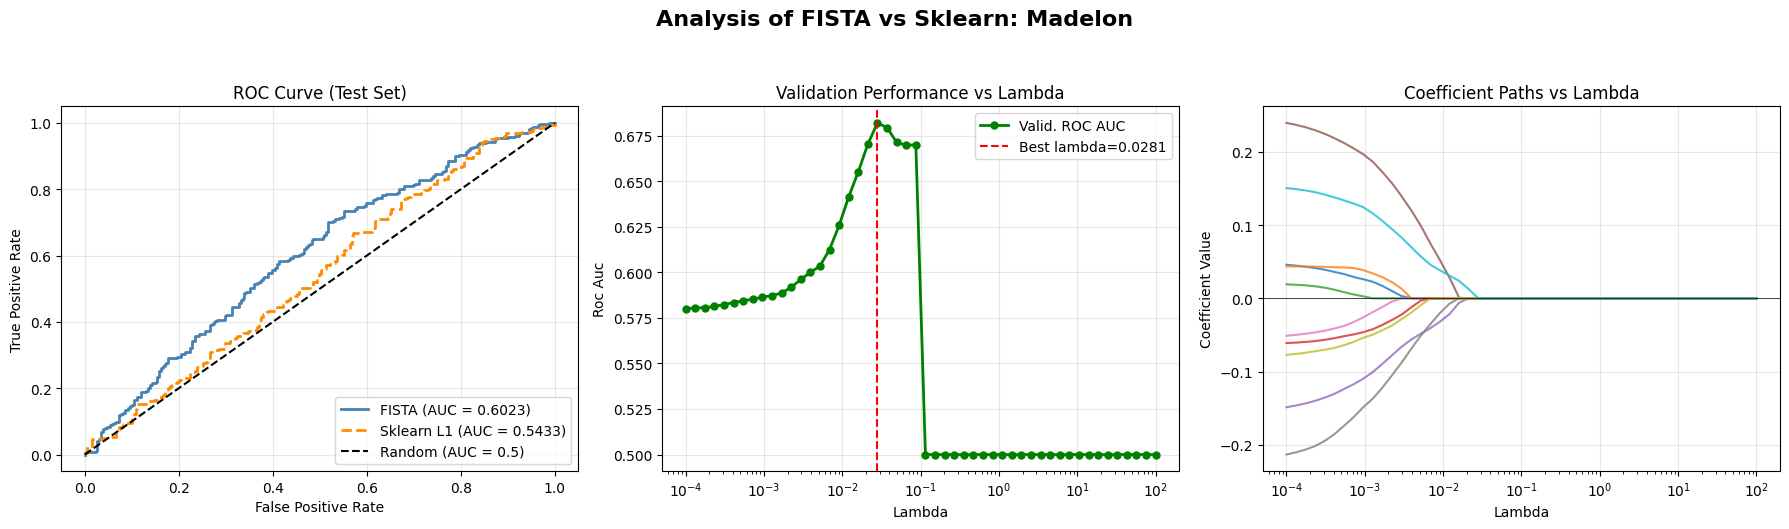


Training and evaluating models for dataset: Car Eval 


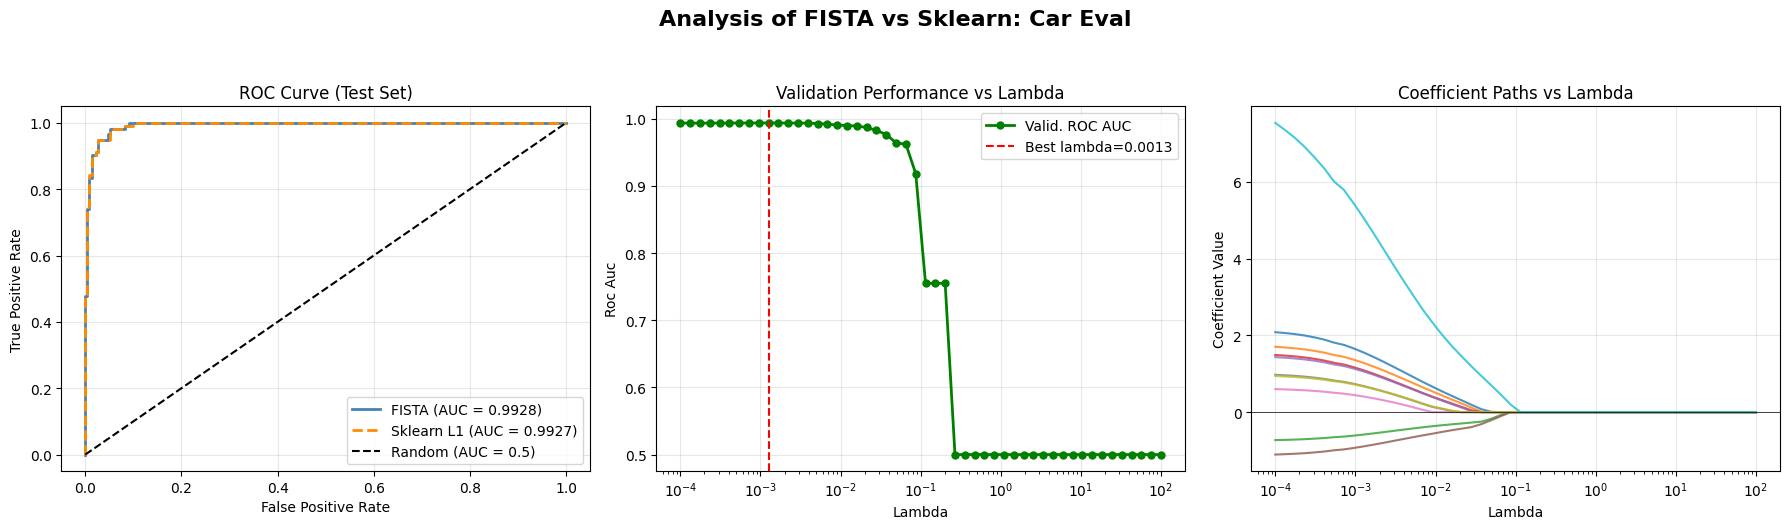


Training and evaluating models for dataset: Speed Dating 


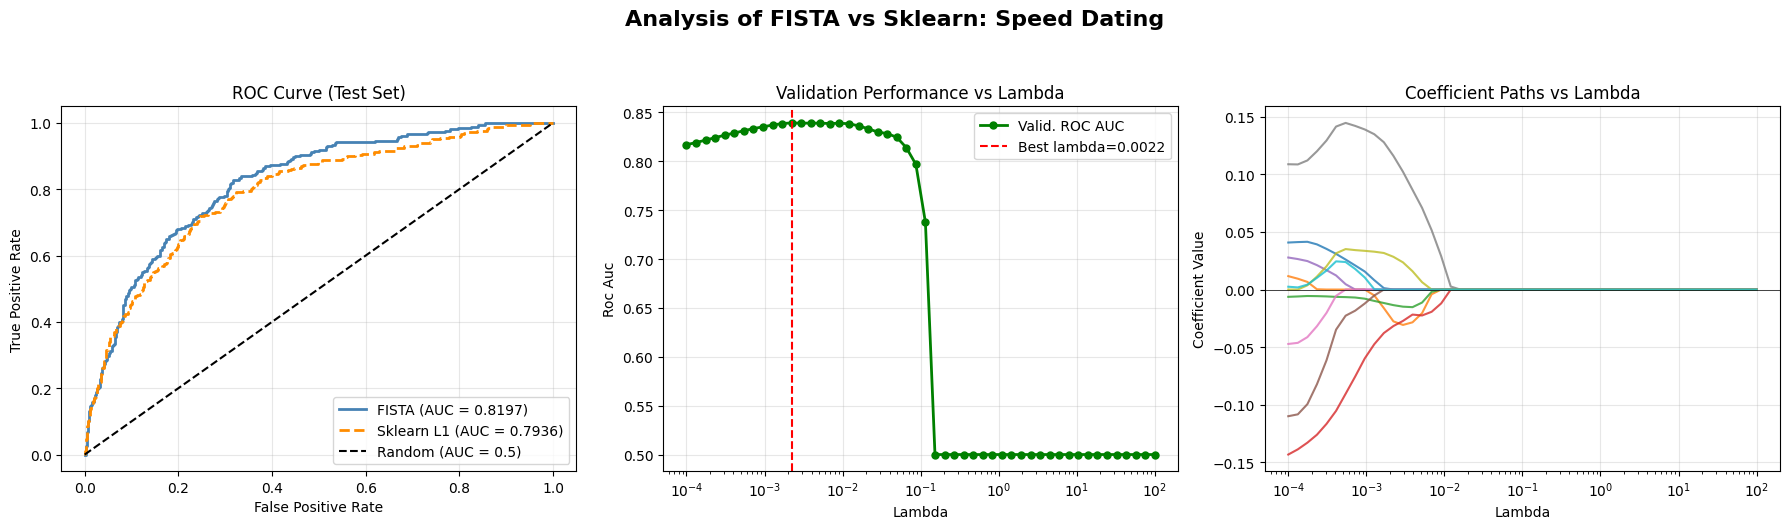


Training and evaluating models for dataset: Student Performance 


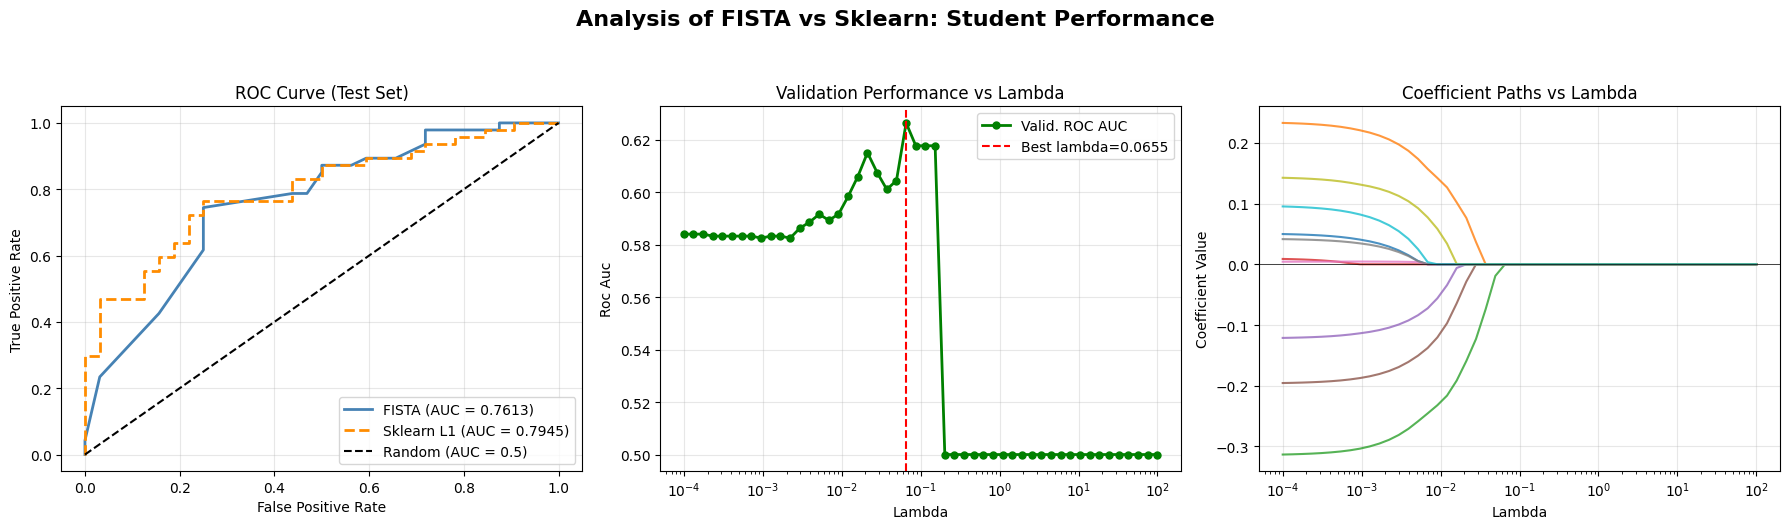

In [29]:
for dataset_name, data_splits in prepared_datasets.items():
    print(f"\n{'='*60}")
    print(f"Training and evaluating models for dataset: {dataset_name} ")
    print(f"{'='*60}")
    
    X_tr = data_splits['X_train']
    y_tr = data_splits['y_train']
    X_val = data_splits['X_valid']
    y_val = data_splits['y_valid']
    X_ts = data_splits['X_test']
    y_ts = data_splits['y_test']
    
    # 1. Training own model (FISTA)
    fista = FistaLogisticRegression(max_iter=1000, X_valid=X_val, y_valid=y_val, measure='roc_auc')
    fista.fit(X_tr, y_tr)

    # 2. Training for comparison (Sklearn)
    sklearn_model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')
    sklearn_model.fit(X_tr, y_tr)
    
    # Predicting probabilities on the test set
    y_pred_prob_fista = fista.predict_proba(X_ts)
    if y_pred_prob_fista.ndim == 2:
        y_pred_prob_fista = y_pred_prob_fista[:, 1]
        
    y_pred_prob_sklearn = sklearn_model.predict_proba(X_ts)[:, 1]
    
    # FPR, TPR and AUC for ROC curve
    fpr_fista, tpr_fista, _ = roc_curve(y_ts, y_pred_prob_fista)
    auc_fista = auc(fpr_fista, tpr_fista)
    
    fpr_skl, tpr_skl, _ = roc_curve(y_ts, y_pred_prob_sklearn)
    auc_skl = auc(fpr_skl, tpr_skl)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Analysis of FISTA vs Sklearn: {dataset_name}', fontsize=16, fontweight='bold', y=1.05)
    
    axes[0].plot(fpr_fista, tpr_fista, label=f'FISTA (AUC = {auc_fista:.4f})', linewidth=2, color='steelblue')
    axes[0].plot(fpr_skl, tpr_skl, label=f'Sklearn L1 (AUC = {auc_skl:.4f})', linewidth=2, color='darkorange', linestyle='--')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve (Test Set)')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    fista.plot(measure='roc_auc', ax=axes[1], label='Valid. ROC AUC', color='green')
    axes[1].set_title('Validation Performance vs Lambda')
    
    fista.plot_coefficients(ax=axes[2], top_n=10)
    axes[2].set_title('Coefficient Paths vs Lambda')
    
    plt.tight_layout()
    plt.show()